In [2]:
import copy, math
import numpy as np 
import matplotlib.pyplot as plt 

In [16]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [15]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

In [10]:
def compute_cost_logistic(X, y, w, b): 
    m = X.shape[0]
    cost = 0.
    for i in range(m): 
        z_i = np.dot(X[i], w) + b 
        f_wb_i = sigmoid(z_i) 
        cost += -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i) 
    cost = cost / m
    return cost

In [11]:
def compute_gradient_logistic(X, y, w, b): 
    """
    Computes the gradient for logistic regression
    X (ndarray(m, n)) 
    y (ndarray(m,)) 
    w (ndarray(n,)) 
    b (scalar) 

    dj_dw (ndarray (n,)) 
    dj_db (scalar) 
    """

    m, n = X.shape 
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m): 
        f_wb_i = sigmoid(np.dot(X[i], w) + b) 
        err_i = f_wb_i - y[i]
        for j in range(n): 
            dj_dw[j] = dj_dw[j] + err_i * X[i, j]
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [8]:
X_tmp = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2., 3.])
b_tmp = 1.
dj_dw, dj_db = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, 1) 
print(f"dj_db: {dj_db}")
print(f"dj_dw: {dj_dw.tolist()}")

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


In [20]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    X (ndarray (m, n)) 
    y (ndarray (m, )) 
    w_in (ndarray (n, )) 
    b_in (scalar) 
    alpha (float) 
    num_iters (scalar) 

    w (ndarray (n, )) 
    b (scalar) 
    """

    # An array to store cost J and w's at each iteration primarily for graphing later 
    J_history = []
    w = copy.deepcopy(w_in) 
    b = b_in 

    for i in range(num_iters): 
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)

        w = w - alpha * dj_dw 
        b = b - alpha * dj_db 

        if i < 100000: 
            J_history.append(compute_cost_logistic(X, y, w, b)) 
        if i % math.ceil(num_iters / 10) == 0: 
            print(f"Iteration {i : 4d} : Cost {J_history[-1]}.    ") 

    return w, b, J_history

In [22]:
w_tmp = np.zeros_like(X_train[0]) 
b_tmp = 0. 
alph = 0.1 
iters = 10000 
w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w{w_out}, b:{b_out}") 

Iteration    0 : Cost 0.684610468560574.    
Iteration  1000 : Cost 0.1590977666870456.    
Iteration  2000 : Cost 0.08460064176930081.    
Iteration  3000 : Cost 0.05705327279402531.    
Iteration  4000 : Cost 0.042907594216820076.    
Iteration  5000 : Cost 0.034338477298845684.    
Iteration  6000 : Cost 0.028603798022120097.    
Iteration  7000 : Cost 0.024501569608793.    
Iteration  8000 : Cost 0.02142370332569295.    
Iteration  9000 : Cost 0.019030137124109114.    

updated parameters: w[5.28123029 5.07815608], b:-14.222409982019837


In [26]:
def plot_data(X, y, ax, pos_label="y=1", neg_label="y=0", s=80, loc='best'): 
    """ plot logistic data with two axis """
    pos = y == 1
    neg = y == 0
    pos = pos.reshape(-1,) #work with 1D y vector 
    neg = neg.reshape(-1,) 

    ax.scatter(X[pos, 0], X[pos, 1], marker='x', s=s, c='r', label=pos_label) 
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', s=s, c='b', label=neg_label) 
    ax.legend(loc=loc) 

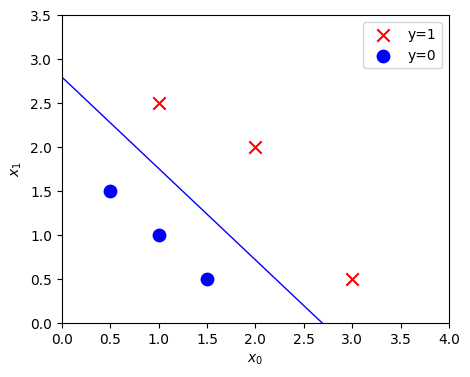

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4)) 

ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$') 
ax.axis([0, 4, 0, 3.5]) 

plot_data(X_train, y_train, ax)
x0 = -b_out / w_out[0]
x1 = -b_out/ w_out[1]
ax.plot([0, x0], [x1, 0], c='b', lw=1)
plt.show()

## Another Data set 


In [36]:
def plt_tumor_data(x, y, ax): 
    """ plots tumor data on one axis """ 
    pos = y == 1
    neg = y == 0

    ax.scatter(x[pos], y[pos], marker='x', s=80, c ='r', label="malignant") 
    ax.scatter(x[neg], y[neg], marker='o', s=100, c='b', label="benign", lw=3)
    ax.set_ylim(-0.175, 1.1) 
    ax.set_ylabel('y') 
    ax.set_xlabel('Tumor size') 
    ax.set_title("Logistic Regression on Categorical Data")

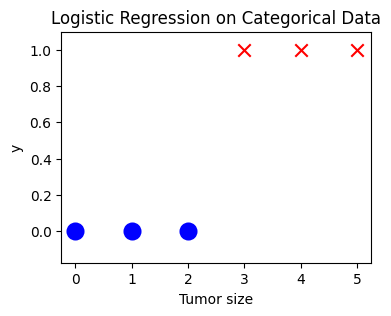

In [37]:
x_train = np.array([0., 1, 2, 3, 4, 5]) 
y_train = np.array([0, 0, 0, 1, 1, 1]) 
fig, ax=plt.subplots(1, 1, figsize=(4, 3)) 
plt_tumor_data(x_train, y_train, ax)